# Clasificación de Vinos utilizando Árboles de Decisión

En este cuaderno se implementa un modelo de clasificación utilizando Árboles de Decisión sobre el conjunto de datos "Wine" del repositorio UCI.  
El objetivo es predecir la clase de un vino en función de características químicas como el contenido de alcohol, magnesio, ácido málico, entre otras.

El flujo de trabajo incluye los siguientes pasos:

1. **Preparación del entorno**: Importación de librerías necesarias de `scikit-learn` y `matplotlib`.
2. **Entrenamiento del modelo**: Se crea un clasificador `DecisionTreeClassifier` utilizando el criterio de entropía y una profundidad máxima de 4, entrenado con los datos previamente divididos.
3. **Visualización del modelo**: Se representa el árbol de decisión tanto en formato de texto como en formato gráfico, para facilitar su interpretación.
4. **Evaluación del rendimiento**: Se evalúa el modelo utilizando métricas de clasificación como precisión, recall, F1-score y una matriz de confusión.

Este análisis permite visualizar cómo el modelo toma decisiones y qué tan eficaz es al clasificar nuevos datos, ofreciendo una herramienta interpretativa valiosa en problemas de clasificación multiclase.


## Instalación de la librería `ucimlrepo`

Se instala el paquete `ucimlrepo`, una librería que permite acceder fácilmente a conjuntos de datos del repositorio de aprendizaje automático de la UCI.


In [ ]:
# ip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importación de librerías principales

Se importan las librerías necesarias para el análisis de datos y visualización:
- `numpy` para operaciones numéricas,
- `pandas` para manipulación de datos,
- `seaborn` y `matplotlib.pyplot` para visualización gráfica.


In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importación de módulos para clasificación con Árboles de Decisión

Se importan herramientas de `scikit-learn` para:
- Dividir los datos en conjuntos de entrenamiento y prueba (`train_test_split`),
- Crear y entrenar un clasificador de árbol de decisión (`DecisionTreeClassifier`),
- Visualizar el árbol de decisión (`tree`),
- Evaluar el rendimiento del modelo (`classification_report`).


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report

## Carga del conjunto de datos "Wine" desde el repositorio UCI

Se utiliza la función `fetch_ucirepo` para descargar el conjunto de datos "Wine" (ID 109) desde el repositorio de aprendizaje automático de la UCI.  
- Se extraen las características (`X`) y las etiquetas (`y`) como `DataFrames`.
- También se imprime la metadata y la información de las variables del conjunto de datos.


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.names)

# variable information
print(wine.variables)


None
                            name     role         type demographic  \
0                          class   Target  Categorical        None   
1                        Alcohol  Feature   Continuous        None   
2                      Malicacid  Feature   Continuous        None   
3                            Ash  Feature   Continuous        None   
4              Alcalinity_of_ash  Feature   Continuous        None   
5                      Magnesium  Feature      Integer        None   
6                  Total_phenols  Feature   Continuous        None   
7                     Flavanoids  Feature   Continuous        None   
8           Nonflavanoid_phenols  Feature   Continuous        None   
9                Proanthocyanins  Feature   Continuous        None   
10               Color_intensity  Feature   Continuous        None   
11                           Hue  Feature   Continuous        None   
12  0D280_0D315_of_diluted_wines  Feature   Continuous        None   
13             

## Visualización de las primeras filas de los datos

Se muestran las primeras cinco filas del conjunto de características (`X`) para tener una vista preliminar de los datos.


In [4]:
X.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Inclusión y transformación de la variable objetivo

Se agrega la columna `Class` al conjunto de datos `X` con las etiquetas de clase.  
Luego, se reemplazan los valores numéricos por etiquetas descriptivas (`class 1`, `class 2`, `class 3`) para facilitar la interpretación.


In [5]:
X['Class'] = y
targets = {1: 'class 1', 2: 'class 2', 3: 'class 3'}
X['Class'] = X['Class'].replace(targets)
X

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,class 1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,class 1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,class 1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,class 1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,class 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,class 3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,class 3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,class 3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,class 3


## Estadísticas descriptivas del conjunto de datos

Se muestran estadísticas descriptivas para todas las columnas del conjunto de datos, incluyendo medidas como media, desviación estándar, valores mínimos, máximos y percentiles.


In [6]:
X.describe(include='all')

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class 2
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,NaN
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,NaN
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,NaN
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,NaN
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,NaN
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,NaN


## Visualización de la distribución de clases según variables

Se crea un gráfico de dispersión utilizando `seaborn` para observar la relación entre las variables `Alcohol` y `Malicacid`, diferenciando las clases por color y estilo.  
Esto permite explorar visualmente la separación entre clases en función de estas dos características.


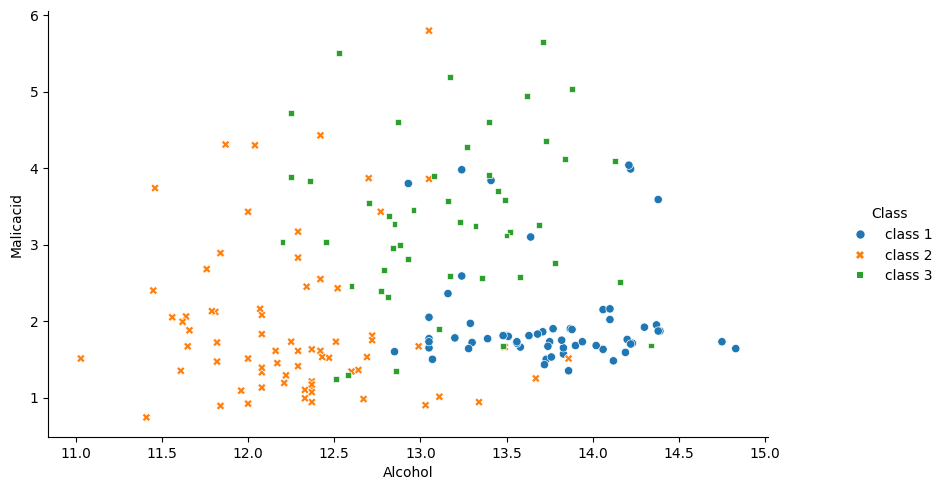

In [7]:
g=sns.relplot(x='Alcohol',y='Malicacid',data=X,hue='Class',style='Class')
g.fig.set_size_inches(10,5)
plt.show()

## Gráfico de dispersión entre `Magnesium` y `Ash` por clase

Se genera un gráfico de dispersión para analizar la relación entre las variables `Magnesium` y `Ash`, distinguiendo las clases mediante colores y estilos.  
Este análisis visual ayuda a identificar posibles patrones o separaciones entre clases.


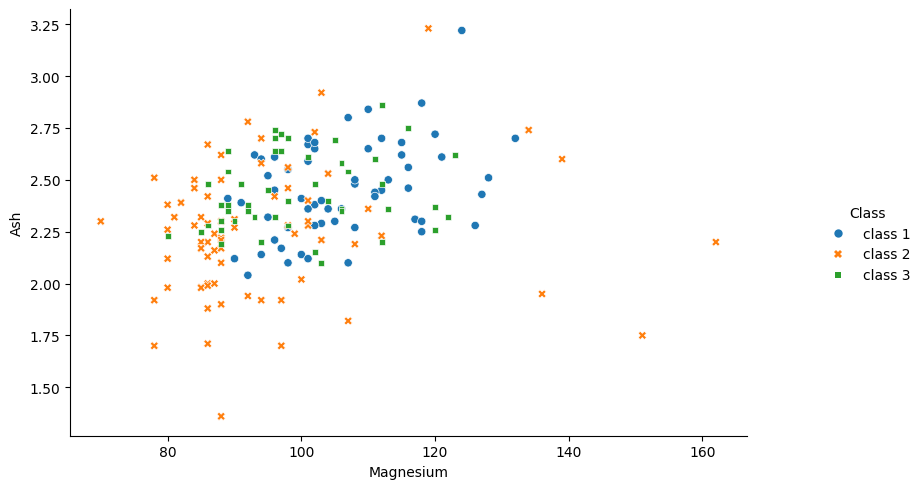

In [8]:
g=sns.relplot(x='Magnesium',y='Ash',data=X,hue='Class',style='Class')
g.fig.set_size_inches(10,5)
plt.show()

## Visualización de distribuciones por clase

Se generan cuatro diagramas de caja (boxplots) para comparar las distribuciones de las variables `Alcohol`, `Malicacid`, `Magnesium` y `Ash` en función de las clases.  
Estos gráficos permiten identificar la mediana, los cuartiles y los valores atípicos para cada clase en cada una de las variables.


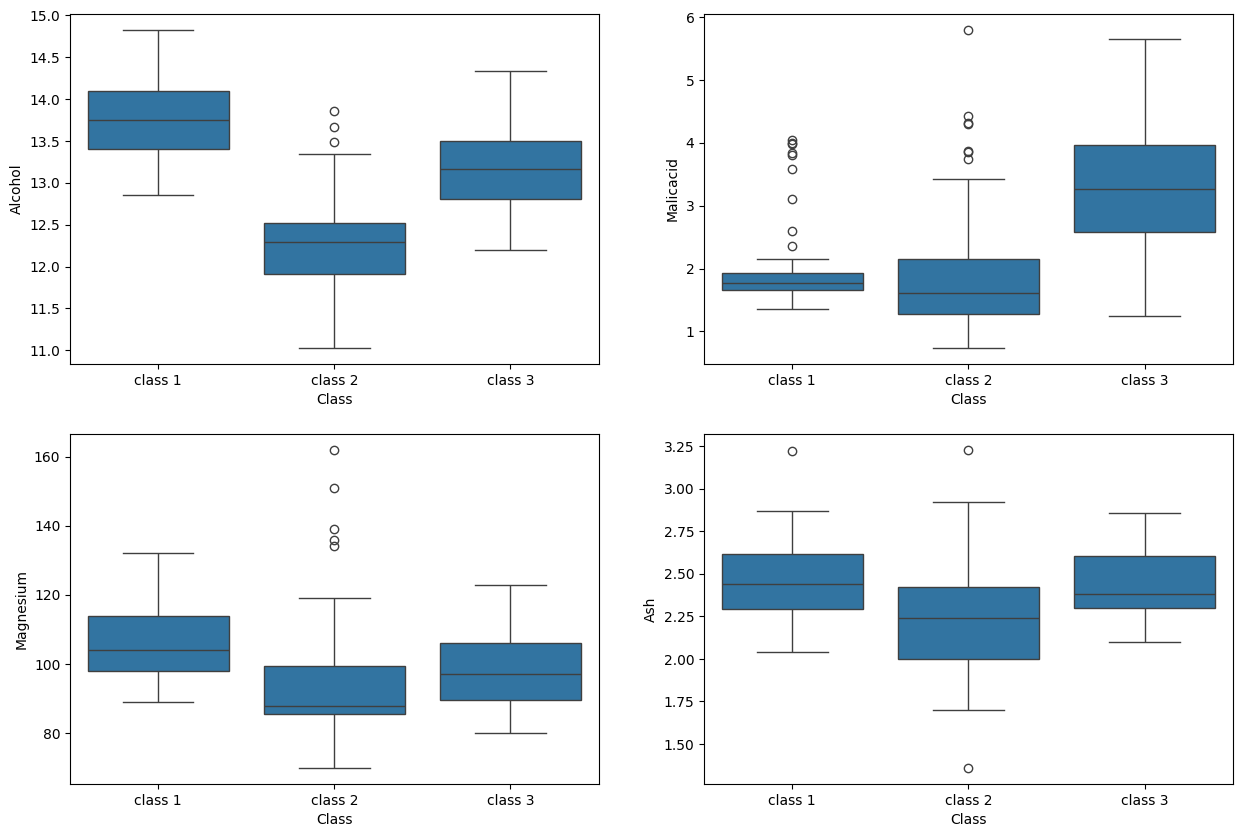

In [9]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.boxplot(x='Class',y='Alcohol',data=X)
plt.subplot(2,2,2)
sns.boxplot(x='Class',y='Malicacid',data=X)
plt.subplot(2,2,3)
sns.boxplot(x='Class',y='Magnesium',data=X)
plt.subplot(2,2,4)
sns.boxplot(x='Class',y='Ash',data=X)
plt.show()

## División de datos en características y etiquetas

Se separan las características (variables predictoras) del conjunto de datos `X`, eliminando la columna `Class`, que representa la etiqueta.  
El resultado es el nuevo conjunto de datos `x`, que contiene solo las características para el modelo.


In [10]:
#Dividing data into features and labels
x = X.drop(columns="Class")
x.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Asignación de la variable objetivo

Se extrae la columna `Class` del conjunto de datos `X` para asignarla como la variable objetivo `y`.  
Esto nos da las etiquetas que el modelo intentará predecir. Se visualizan las primeras filas de `y`.


In [11]:
y = X["Class"]
y.head()

0    class 1
1    class 1
2    class 1
3    class 1
4    class 1
Name: Class, dtype: object

## División del conjunto de datos en entrenamiento y prueba

Se divide el conjunto de datos en dos partes: entrenamiento (70%) y prueba (30%), utilizando la función `train_test_split`.  
El parámetro `random_state` asegura que la división sea reproducible. Esto prepara los datos para entrenar y evaluar el modelo.


In [12]:
### Se divide el dataset en trainin and testing
X_train, X_test, y_train, y_test = train_test_split(x,y,
                                                 test_size = 0.3,
                                                 random_state = 42)

## Visualización de las primeras filas del conjunto de entrenamiento

Se muestran las primeras cinco filas del conjunto de entrenamiento `X_train` para inspeccionar las características utilizadas para el entrenamiento del modelo.


In [13]:
X_train.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580
104,12.51,1.73,1.98,20.5,85,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672
78,12.33,0.99,1.95,14.8,136,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750
36,13.28,1.64,2.84,15.5,110,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880
93,12.29,2.83,2.22,18.0,88,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290


## Entrenamiento del modelo de Árbol de Decisión

Se crea e entrena un clasificador de árbol de decisión utilizando el criterio de entropía para la toma de decisiones, con una profundidad máxima de 4 niveles (`max_depth=4`).  
El modelo es ajustado con el conjunto de entrenamiento `X_train` y las etiquetas `y_train`.


In [15]:
# Fit the classifier with default hyper-parameters
desicionTree = DecisionTreeClassifier(random_state=1234, criterion="entropy", max_depth=4)
#desicionTree = DecisionTreeClassifier(random_state=1234)
model = desicionTree.fit(X_train, y_train)

## Visualización del Árbol de Decisión en formato de texto

Se exporta y muestra una representación textual del árbol de decisión entrenado.  
Esta visualización proporciona una forma de interpretar las decisiones tomadas por el modelo en función de las características de los datos.


In [17]:
text_representation = tree.export_text(desicionTree)
print(text_representation)

|--- feature_11 <= 2.19
|   |--- feature_10 <= 0.90
|   |   |--- feature_8 <= 1.59
|   |   |   |--- class: class 3
|   |   |--- feature_8 >  1.59
|   |   |   |--- class: class 2
|   |--- feature_10 >  0.90
|   |   |--- feature_6 <= 0.56
|   |   |   |--- class: class 3
|   |   |--- feature_6 >  0.56
|   |   |   |--- class: class 2
|--- feature_11 >  2.19
|   |--- feature_0 <= 12.79
|   |   |--- class: class 2
|   |--- feature_0 >  12.79
|   |   |--- feature_9 <= 3.82
|   |   |   |--- feature_1 <= 1.76
|   |   |   |   |--- class: class 2
|   |   |   |--- feature_1 >  1.76
|   |   |   |   |--- class: class 1
|   |   |--- feature_9 >  3.82
|   |   |   |--- class: class 1



## Definición de nombres de características y clases

Se asignan los nombres de las características del conjunto de datos `x` a la variable `feature_names`, que contiene las columnas del conjunto de entrenamiento.  
También se definen los nombres de las clases (`class_names`), que corresponden a las etiquetas del conjunto de datos: `class 1`, `class 2`, y `class 3`.


In [ ]:
feature_names=list(x.columns)
print(feature_names)
class_names=['class 1', 'class 2', 'class 3']
print(class_names)


['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']


## Visualización gráfica del Árbol de Decisión

Se genera una representación gráfica del árbol de decisión entrenado, mostrando las características y clases utilizadas para las decisiones.  
Este gráfico proporciona una manera visual de comprender cómo el modelo clasifica las instancias en función de las características. La opción `filled=True` colorea los nodos según las clases para mejorar la interpretación.


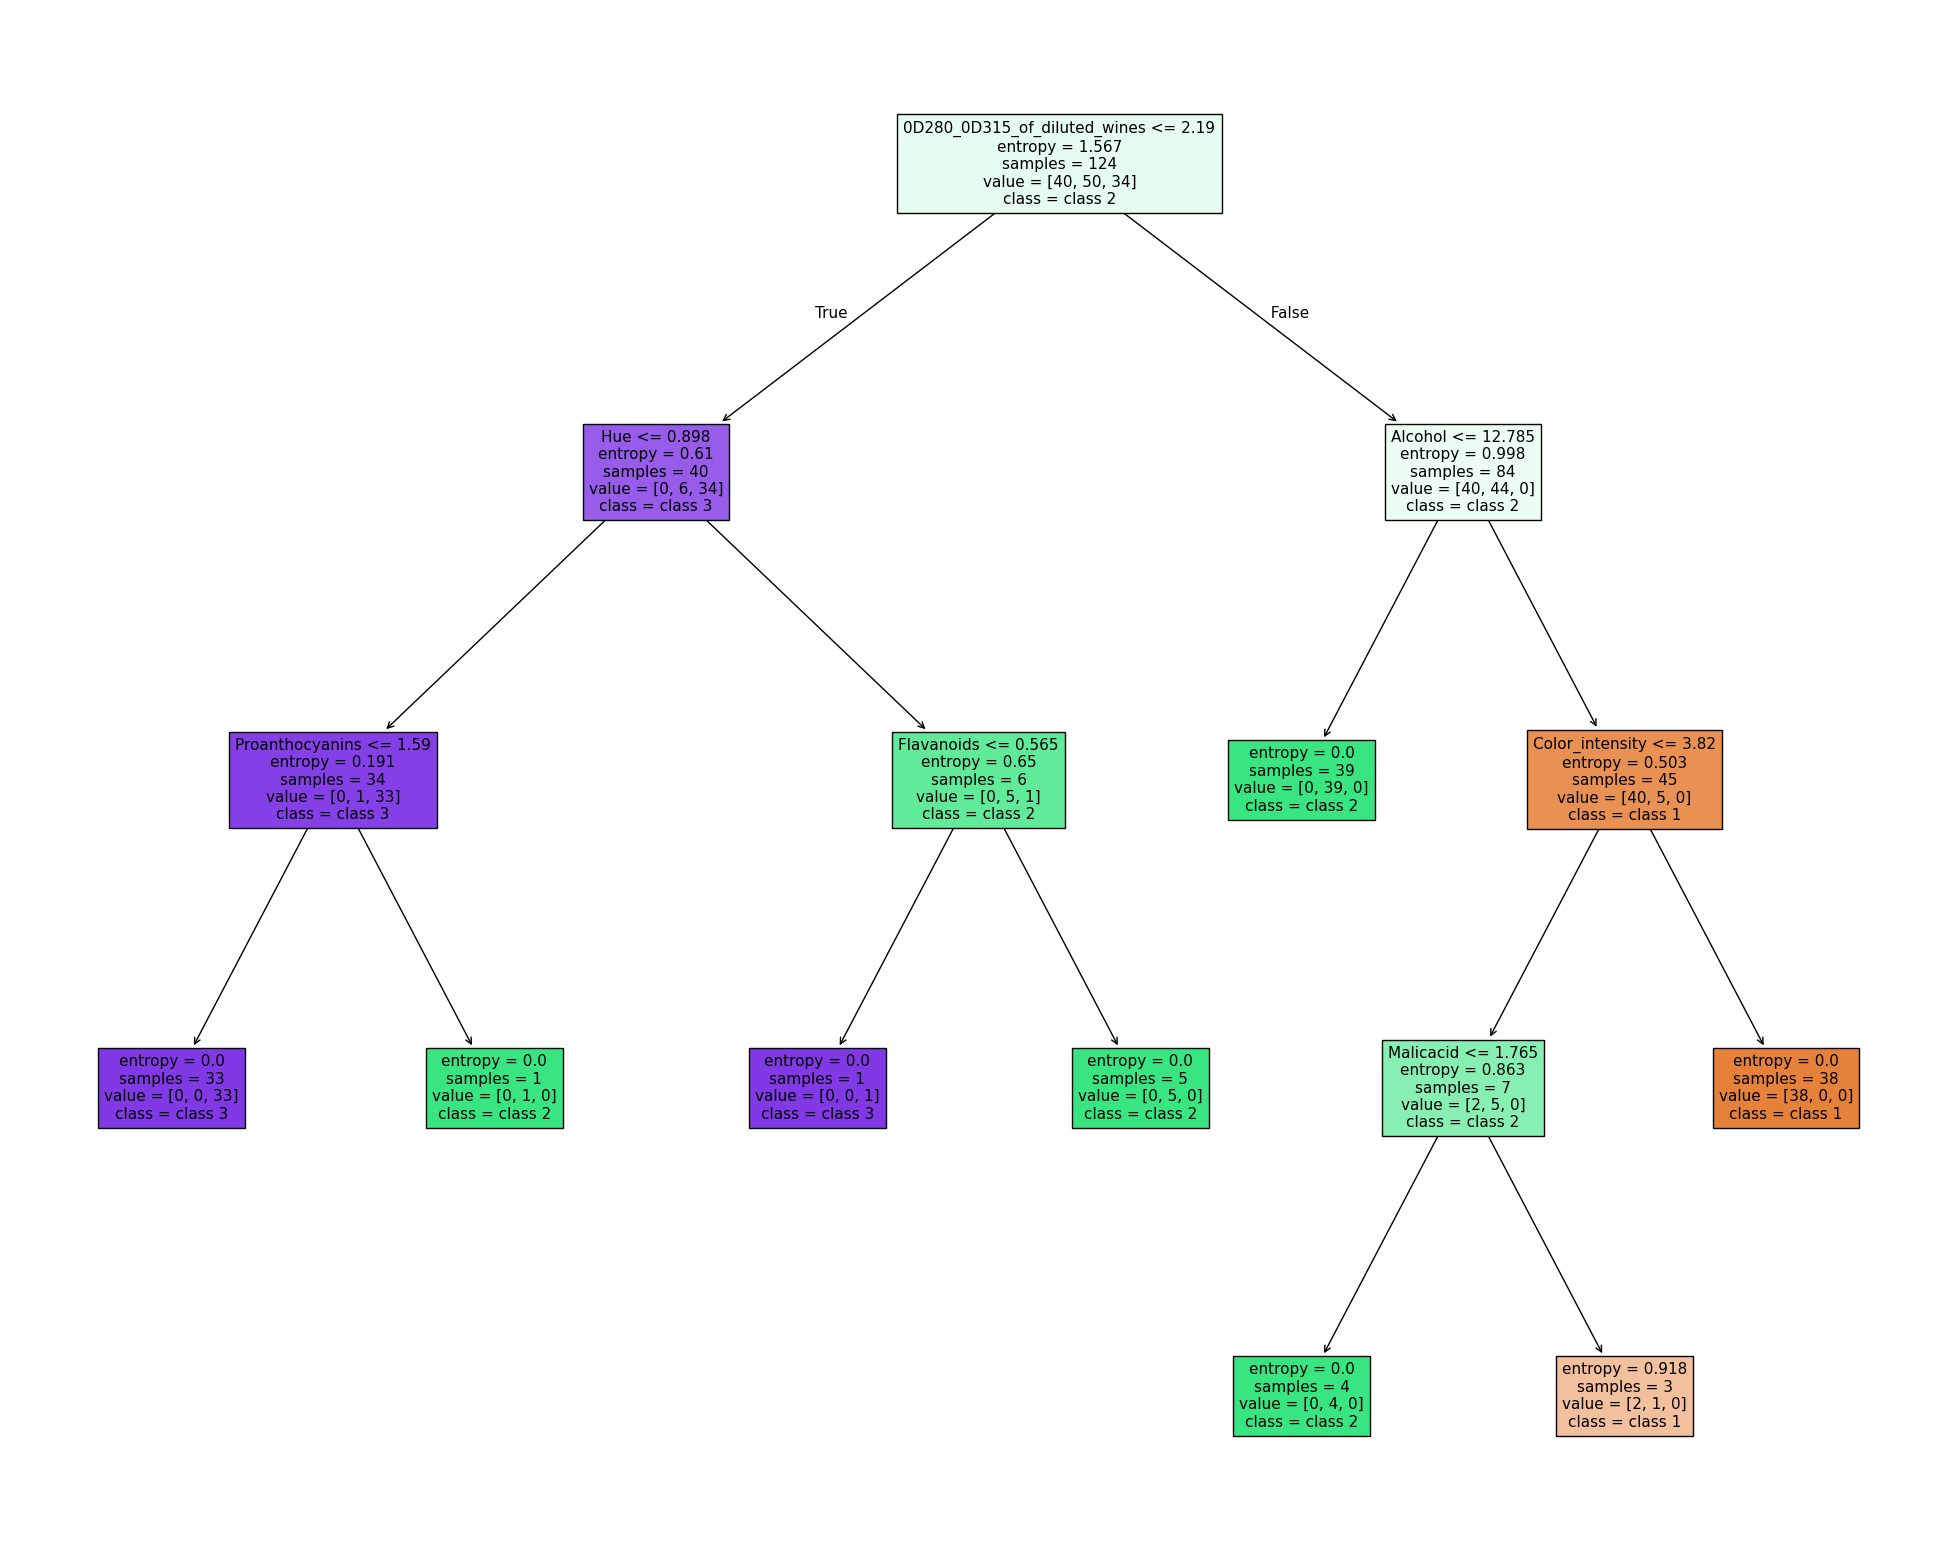

In [29]:
fig = plt.figure(figsize=(25,20))
tree_plot = tree.plot_tree(desicionTree, 
                   feature_names=list(x.columns),  
                   class_names=['class 1', 'class 2', 'class 3'],
                   filled=True)

## Predicción de clases en el conjunto de prueba

Se utiliza el modelo entrenado para predecir las clases de los datos de prueba (`X_test`).  
Las predicciones se almacenan en la variable `y_pred`, que contiene las etiquetas predichas por el modelo para el conjunto de prueba.


In [30]:
#### Vamos a probar el modelo, X_test tiene los datos de prueba
### la variable y_pred contiene los datos que predice el modelo.
y_pred = model.predict(X_test)

## Evaluación del rendimiento del modelo

Se imprime un informe de clasificación utilizando `classification_report`, que muestra métricas como precisión, recall, F1-score y soporte para cada clase.  
Este informe es útil para evaluar la efectividad del clasificador de árbol de decisión en el conjunto de prueba.


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     class 1       0.82      0.95      0.88        19
     class 2       0.78      0.86      0.82        21
     class 3       0.89      0.57      0.70        14

    accuracy                           0.81        54
   macro avg       0.83      0.79      0.80        54
weighted avg       0.82      0.81      0.81        54



## Cálculo de la precisión del modelo

Se calcula y muestra la precisión del modelo utilizando `accuracy_score`, que mide la proporción de predicciones correctas en el conjunto de prueba.  
Este valor proporciona una medida general de la efectividad del clasificador de árbol de decisión.


In [34]:
from sklearn.metrics import accuracy_score
print('accuracy is',accuracy_score(y_pred,y_test))

accuracy is 0.8148148148148148


## Matriz de confusión

Se genera e imprime la matriz de confusión utilizando `confusion_matrix`, que muestra el número de predicciones correctas e incorrectas clasificadas por cada clase.  
Esta matriz ayuda a entender cómo el modelo ha clasificado correctamente o ha confundido las distintas clases en el conjunto de prueba.


In [35]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[18  1  0]
 [ 2 18  1]
 [ 2  4  8]]
